In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path().resolve().parent
PROC_DIR = BASE_DIR / "data" / "processed"

nav  = pd.read_csv(PROC_DIR / "clean_nav.csv", parse_dates=["date"])
perf = pd.read_csv(PROC_DIR / "clean_performance.csv")

nav.sort_values(['amfi_code', 'date'], inplace=True)
print("Data loaded!")

Data loaded!


In [4]:
# Daily returns
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

# Annualised return per fund
def annualised_return(x):
    return (1 + x).prod() ** (252 / len(x)) - 1

annual = nav.groupby('amfi_code')['daily_return'].apply(annualised_return).reset_index()
annual.columns = ['amfi_code', 'annualised_return']

print(annual.head())
annual.to_csv(PROC_DIR / "returns_computed.csv", index=False)
print("returns_computed.csv saved!")

   amfi_code  annualised_return
0     100016           0.025412
1     100025           0.042948
2     100033           0.288994
3     101206           0.226048
4     101207           0.076433
returns_computed.csv saved!


In [6]:
def cagr(nav_group, years):
    nav_group = nav_group.sort_values('date')
    end = nav_group['nav'].iloc[-1]
    cutoff = nav_group['date'].iloc[-1] - pd.DateOffset(years=years)
    start_row = nav_group[nav_group['date'] >= cutoff]
    if start_row.empty:
        return None
    start = start_row['nav'].iloc[0]
    return (end / start) ** (1 / years) - 1

cagr_results = []
for code, group in nav.groupby('amfi_code'):
    cagr_results.append({
        'amfi_code' : code,
        'cagr_1yr'  : cagr(group, 1),
        'cagr_3yr'  : cagr(group, 3),
        'cagr_5yr'  : cagr(group, 5)
    })

cagr_df = pd.DataFrame(cagr_results)
print(cagr_df.head())
cagr_df.to_csv(PROC_DIR / "cagr_report.csv", index=False)
print("cagr_report.csv saved!")

   amfi_code  cagr_1yr  cagr_3yr  cagr_5yr
0     100016 -0.022243  0.012926  0.023168
1     100025  0.037050  0.039164  0.039127
2     100033  0.532324  0.324425  0.260741
3     101206  0.479241  0.289677  0.204427
4     101207 -0.239860 -0.041524  0.069533
cagr_report.csv saved!


In [7]:
RF = 0.065 / 252  # RBI repo rate daily

sharpe_results = []
for code, group in nav.groupby('amfi_code'):
    excess = group['daily_return'] - RF
    sharpe = (excess.mean() / excess.std()) * np.sqrt(252)
    sharpe_results.append({'amfi_code': code, 'sharpe_ratio': sharpe})

sharpe_df = pd.DataFrame(sharpe_results)
print(sharpe_df.head())
sharpe_df.to_csv(PROC_DIR / "sharpe_values.csv", index=False)
print("sharpe_values.csv saved!")

   amfi_code  sharpe_ratio
0     100016     -0.201517
1     100025     -0.567095
2     100033      1.093699
3     101206      1.027213
4     101207      0.162661
sharpe_values.csv saved!


In [8]:
sortino_results = []
for code, group in nav.groupby('amfi_code'):
    excess = group['daily_return'] - RF
    downside = excess[excess < 0].std()
    sortino = (excess.mean() / downside) * np.sqrt(252)
    sortino_results.append({'amfi_code': code, 'sortino_ratio': sortino})

sortino_df = pd.DataFrame(sortino_results)
print(sortino_df.head())
sortino_df.to_csv(PROC_DIR / "sortino_values.csv", index=False)
print("sortino_values.csv saved!")

   amfi_code  sortino_ratio
0     100016      -0.348196
1     100025      -0.915371
2     100033       1.823824
3     101206       1.785592
4     101207       0.274615
sortino_values.csv saved!


In [11]:
# Use nav dataframe which already has daily_return computed
nifty = nav[nav['amfi_code'] == nav['amfi_code'].iloc[0]][['date', 'daily_return']].copy()
nifty.columns = ['date', 'benchmark_return']

ab_results = []
for code, group in nav.groupby('amfi_code'):
    merged = group[['date', 'daily_return']].merge(nifty, on='date', how='inner').dropna()
    if len(merged) < 30:
        continue
    slope, intercept, _, _, _ = stats.linregress(
        merged['benchmark_return'], merged['daily_return']
    )
    ab_results.append({
        'amfi_code' : code,
        'beta'      : slope,
        'alpha'     : intercept * 252
    })

ab_df = pd.DataFrame(ab_results)
print(ab_df.head())
ab_df.to_csv(PROC_DIR / "alpha_beta.csv", index=False)
print("alpha_beta.csv saved!")

   amfi_code      beta     alpha
0     100016  1.000000  0.000000
1     100025  0.012232  0.042417
2     100033 -0.000008  0.272111
3     101206  0.027785  0.213655
4     101207  0.028466  0.105946
alpha_beta.csv saved!


In [13]:
dd_results = []
for code, group in nav.groupby('amfi_code'):
    group = group.sort_values('date')
    running_max = group['nav'].cummax()
    drawdown = (group['nav'] / running_max) - 1
    max_dd = drawdown.min()
    worst_date = drawdown.idxmin()
    dd_results.append({
        'amfi_code'    : code,
        'max_drawdown' : max_dd,
        'worst_date'   : group.loc[worst_date, 'date']
    })

dd_df = pd.DataFrame(dd_results)
print(dd_df.head())
dd_df.to_csv(PROC_DIR / "max_drawdown.csv", index=False)
print("max_drawdown.csv saved!")

   amfi_code  max_drawdown worst_date
0     100016     -0.247344 2022-09-15
1     100025     -0.043083 2023-07-28
2     100033     -0.162172 2022-05-12
3     101206     -0.112916 2023-07-05
4     101207     -0.354469 2026-05-11
max_drawdown.csv saved!


In [14]:
# Merge all metrics
scorecard = cagr_df[['amfi_code', 'cagr_3yr']].merge(
    sharpe_df, on='amfi_code').merge(
    ab_df[['amfi_code', 'alpha']], on='amfi_code').merge(
    dd_df[['amfi_code', 'max_drawdown']], on='amfi_code').merge(
    perf[['amfi_code', 'expense_ratio_pct']], on='amfi_code')

# Rank each metric (higher is better except expense & drawdown)
scorecard['cagr_rank']    = scorecard['cagr_3yr'].rank(pct=True)
scorecard['sharpe_rank']  = scorecard['sharpe_ratio'].rank(pct=True)
scorecard['alpha_rank']   = scorecard['alpha'].rank(pct=True)
scorecard['expense_rank'] = scorecard['expense_ratio_pct'].rank(pct=True, ascending=False)
scorecard['dd_rank']      = scorecard['max_drawdown'].rank(pct=True, ascending=False)

# Weighted score
scorecard['score'] = (
    0.30 * scorecard['cagr_rank']    +
    0.25 * scorecard['sharpe_rank']  +
    0.20 * scorecard['alpha_rank']   +
    0.15 * scorecard['expense_rank'] +
    0.10 * scorecard['dd_rank']
) * 100

scorecard = scorecard.sort_values('score', ascending=False)
print(scorecard[['amfi_code', 'score']].head(10))
scorecard.to_csv(PROC_DIR / "fund_scorecard.csv", index=False)
print("fund_scorecard.csv saved!")

    amfi_code    score
25     120505  84.5000
2      100033  81.0000
16     119094  80.7500
34     148567  80.0000
30     120843  77.7500
24     120504  75.7500
21     119598  75.1250
39     149324  74.9375
36     148569  73.9375
19     119551  73.0625
fund_scorecard.csv saved!


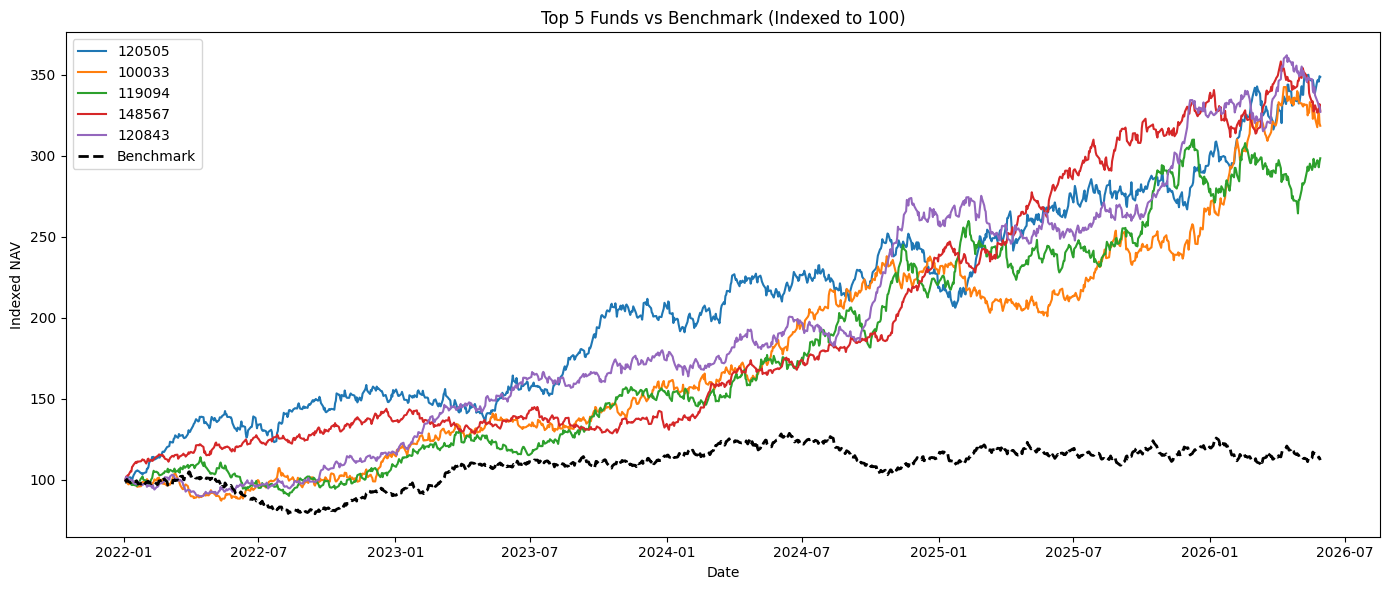

In [15]:
# Top 5 funds by score
top5 = scorecard.head(5)['amfi_code'].tolist()

# Get benchmark (use first fund as proxy if no Nifty data)
benchmark_nav = nav[nav['amfi_code'] == nav['amfi_code'].iloc[0]][['date', 'nav']].copy()
benchmark_nav['nav'] = benchmark_nav['nav'] / benchmark_nav['nav'].iloc[0] * 100

plt.figure(figsize=(14, 6))

for code in top5:
    fund_nav = nav[nav['amfi_code'] == code][['date', 'nav']].copy()
    fund_nav['nav'] = fund_nav['nav'] / fund_nav['nav'].iloc[0] * 100
    plt.plot(fund_nav['date'], fund_nav['nav'], label=str(code))

plt.plot(benchmark_nav['date'], benchmark_nav['nav'],
         label='Benchmark', linestyle='--', color='black', linewidth=2)

plt.title("Top 5 Funds vs Benchmark (Indexed to 100)")
plt.xlabel("Date")
plt.ylabel("Indexed NAV")
plt.legend()
plt.tight_layout()
plt.savefig(BASE_DIR / "reports" / "benchmark_chart.png")
plt.show()